#Simulación

Para este ejercicio se generaron 500 muestras de una variable uniforme X, en la que la vamos a utilizar para condicionar a la variable Y que es una normal con media dependiente de X, definida como X en el plano positivo del eje x, de esta manera es cuando implementamos la función  ReLU.
Luego se procedio a gráficar la variable condicional Y|X, lo que vemos con una desviación significativa, son las muestras de (-1,0) que tienden a estar por sobre el eje x, y luego de (0,1) vemos como hay una tendencia de las muestras al crecimiento de forma puede decirse lineal.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

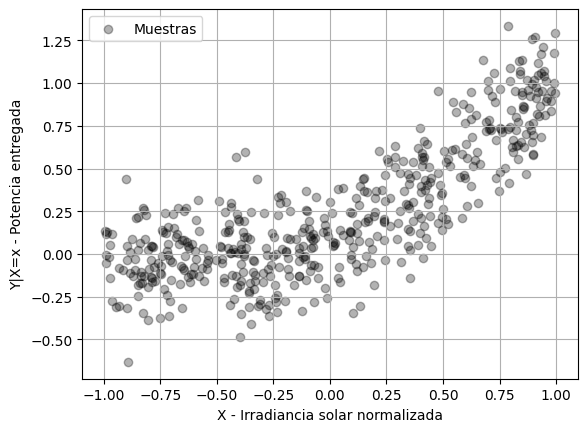

In [ ]:
#Parametros
N = 500 #Cantidad de muestras
sigma_cuad = 0.04

X = np.random.uniform(-1, 1, N) #Distribución uniforme de X usando np.random.uniform
r = np.where(X > 0, X, 0) #Funcion ReLU
Y = np.random.normal(r,np.sqrt(sigma_cuad)) #Distribución normal de Y|X = x

#Grafico

plt.scatter(X,Y, color = "black", label = "Muestras",alpha = 0.3)
plt.xlabel("X - Irradiancia solar normalizada")
plt.ylabel("Y|X=x - Potencia entregada")
plt.legend()
plt.grid(True)
plt.show()



#Analisis Teorico

Calculo analiticamente la esperanza de X, como sabemos de materias como Probabilidad y Estadistica, la esperanza de X es:
$E[X] = \frac{a+b}{2}$, siendo en este caso a = 1, y b = -1, por lo tanto tenemos que la esperanza es cero, esto quiere decir que la variable X tiende a ser cero. Luego se calculo la varianza, que es cuanto varia X, siendo de $Var(X)= \frac{1}{3}$.

Luego, para calcular la variable condicional Y, utilizamos la esperanza condicional, de manera que nos lleva a calcular la esperanza condicional Y|X, siendo esta la función ReLU, podriamos calcular mediante integrales, pero como se trata de una función uniforme, la esperanza es igual al área encerrada por la ReLU, siendo un triangulo establecido en el plano. La esperanza de Y termina siendo de $\frac{1}{4}$.

Para calcular la varianza, usamos la formula que esta relacionada con la esperanza, de esta manera solo nos quedaria calcular la esperanza de la ReLU al cuadrado, en este caso es necesitario calcular mediante la integral:


$E[(r(x)^2)] = \int_0^1 x^2\frac{1}{2}dx= \frac{1}{6}$.

Como tenemos la esperanza de r(x), ya podemos calcular la varianza de Y:

$Var(r(x))= E[Var(Y|X)] + Var[E(Y|X)] = \sigma^2 + Var[r(x)]$

Calculo $Var[r(x)]$:


$Var(r(x))= E[r(x)^2] - E[r(x)]^2= \frac{1}{6}-\frac{1}{16} = \frac{5}{48}$

Por lo tanto la varianza de Y

$Var(Y) = 0.04 + \frac{5}{48} = \frac{173}{1200} ≈ 0.14$

El siguiente paso fue calcular $E[XY]$, en este caso volvemos a usar lo que es la ley de esperanza total:

$E[XY]=E[E(XY|X)]$

$E[XY|X]= xE[Y|X] = x r(x) = x^2{x>0}$

Por lo tanto tenemos que $E[XY] = E[r(x)^2]$, el cual ya calculamos anteriormente, por lo que $E[XY] = \frac{1}{6}$

##Función de regresión optima

La función de regresión optima esta definida como:

$ϕ*(x)=E[Y|X=x] = r(x)$

por lo que podemos decir que la ReLU es nuestra función de regresión óptima.

##Error Bayesiano

El error bayesiano se refiere al minimo error de predicción posible, siendo la esperanza de la varianza:

$R(ϕ*)= E[Var(Y|X) = 0.04= \sigma^2]$

#Mejor predictor sin observar X

En el caso que no contemos con X, el mejor predicador será el que minimice el error cuadratico medio (MSE), de manera que el procedimiento para hallarlo será buscar un valor k constante que será nuestro predictor que minimice el MSE, si desarrollamos el MSE:

$MSE = E[(Y-k)^2] = E[Y^2]-2E[Y⋅K]+ E[k^2]$

Para hallar el valor de k que minimice el MSE, derivamos con respecto a k e igualamos a cero:

$\frac{∂MSE}{∂k}= -2E[Y] + 2k = 0$

Por lo que vemos que el valor que minimiza el MSE, es la esperanza de Y, siendo esta de 1/4, por lo que $k = \frac{1}{4}$

El error del predictor sin observar X, es la varianza Y, dado que es lo que puede llegar a variar el predictor. La cual es 0.14.

##Comparación del regresor optimo con el mejor predictor

Como vemos entre el error bayesiano y el error del predictor, hay una diferencia de un orden, mientras que el error bayesiano es de 0.04, el error del predictor es de 0.14, ambos tienen un error porcentual del 250%.







#Regresión Lineal

A partir de los datos generados, implemento una regresión lineal matricial.
Primero armo la función fit, encargada de entrena la regresión lineal con la data generada anteriormente, esto esta definido como $(X^T X)^{-1} X^T y$, por lo que primero creo un vector de '1' para ajustar lo que es el vector X a una matriz, luego genero el calculo de los parametros w.

Luego de la etapa de entrenamiento, paso a la etapa de testeo, en la que hallo $y$ , esto es para verificar que tan bien el predictor aprendio de los datos.

El paso siguiente es el del computo del error, el cual es mediante el MSE.

In [ ]:
class RegLineal:
  def __init__(self):
    self.params = None
# Entrenar la regresión lineal con el dataset generado anteriormente. w = (X^T X)^-1 X^T y
  def fit(self,X,y):
    X_matriz = np.c_[np.ones((X.shape[0],1)), X] #Crea un vector de '1' y en base a eso crea una matriz al juntar ese vector con el vector de muestras X
    w = (np.linalg.inv(X_matriz.T @ X_matriz)@ X_matriz.T )@y
    self.params = w

# Etapa de testeo
  def predict(self,X):
    X_matriz = np.c_[np.ones((X.shape[0],1)), X] #Matriz aumentada
    return X_matriz @ self.params  # y = w_0 + w_1*x vector de prediciones

#Computo del error
  def err_predict(self, X, y):
    y_p = self.predict(X)
    return np.mean((y - y_p)**2)  #MSE

Para esta sección voy a probar el modelo de regresión generado, lo que quiero predecir es la potencia generada para una irradiancia de 0.5. Teniendo en cuenta esto, genero un modelo teniendo en cuenta el valor de la irradiancia y la función de predict, esto lo gráfico lo que me generara un regresor lineal definido por la recta roja. Luego vemos que tanto el regresor optimo como las muestras generadas por Y condicional, estas ultimas tienen una tendencia a la optimización.


Error de entrenamiento:  0.05573973223462835
Predicción de Y con X = 0.5:  [0.50700501]


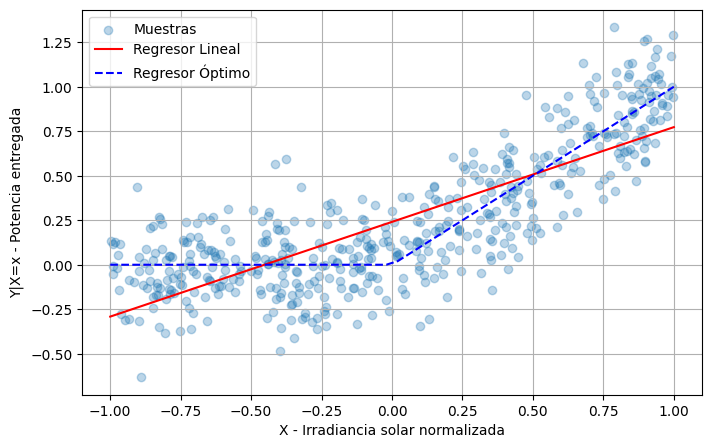

In [ ]:
modelo = RegLineal()
modelo.fit(X,Y)

#Error de entrenamiento
error = modelo.err_predict(X,Y)
print("Error de entrenamiento: ",error)

# Utilizar el regresor para predecir la potencia producida para una irradiancia de 0.5

irradiancia = np.array([0.5])
y_i = modelo.predict(irradiancia)
print("Predicción de Y con X = 0.5: ",y_i)

#Graficar el regresor obtenido superpuesto al ´optimo y al scatter.
plt.figure(figsize=(8,5))
plt.grid()
plt.scatter(X,Y,alpha=0.3,label="Muestras") #Muestras
# Regresor lineal aprendido
x_line = np.linspace(-1,1)
y_line = modelo.predict(x_line)
plt.plot(x_line,y_line,label="Regresor Lineal",color = "red")
plt.plot(x_line,np.where(x_line > 0, x_line,0),'b--',label="Regresor Óptimo")
plt.xlabel("X - Irradiancia solar normalizada")
plt.ylabel("Y|X=x - Potencia entregada")
plt.legend()
plt.show()

#Gradiente Descendiente

Para en este caso, usamos el método del gradiente descendiente, para este caso teniendo en cuenta el MSE matricial:

$MSE[w]= \frac{1}{n}(y-Xw)^T(y-Xw)= y^Ty -2y^TXw + w^TX^TXw$

Hallo el gradiente del MSE respecto a w, teniendo en cuenta que $y^Ty$ es una constante respecto a w, $2y^TXw$ es lineal en w, y $w^TX^TXw$ es cuadratica en w, aplico las reglas de derivación matricial, dandome como resultado:

$\frac{∂MSE(w)}{∂w}= \frac{1}{n}(0-2X^Ty + 2X^TXw)=\frac{2}{n}X^T(Xw-y)$

La idea es avanzar en forma iterativa en la dirección del máximo crecimiento, teniendo en cuenta el gradiente y el learning rate, el learning rate es un hiper-parametro que mientras mas chico es mas lento converge, y mientras mas alto mas la convergencia es más rapida e incluso puede llegar a diverger en un cierto valor.

In [ ]:
class RegLineal_2:
  def __init__(self):
    self.params = None
    self.w = []

# Entrenar la regresión lineal con el dataset generado anteriormente. w = (X^T X)^-1 X^T y
  def fit_gradient(self,X,y,learning_rate):
    X_matriz = np.c_[np.ones((X.shape[0],1)), X] #Crea un vector de '1' y en base a eso crea una matriz al juntar ese vector con el vector de muestras X
    y = y.reshape(-1,1)  # (n,1) Matriz columna
    self.params = np.zeros((2,1))  # inicializar parámetros
    self.w = []
    n = X_matriz.shape[0]
    for _ in range(n):
            y_p = X_matriz @ self.params # x * w
            grad = (2 / n) * X_matriz.T @ (y_p - y) # gradiente del MSE
            self.params -= learning_rate * grad #Actualiza los parametros moviendo en direccion opuesta al gradiente
            self.w.append(self.params[1,0])

# Etapa de testeo
  def predict(self,X):
    X_matriz = np.c_[np.ones((X.shape[0],1)), X] #Matriz aumentada
    return X_matriz @ self.params  # y = w_0 + w_1*x vector de prediciones

#Computo del error
  def err_predict(self, X, y):
    y_p = self.predict(X)
    return np.mean((y - y_p)**2)  #MSE

Hacemos uso de este modelo de la misma manera que hicimos con el regresor lineal, lo que vemos es que ambos se comportan de igual manera, dandonos la pauta de que se tratan de modelos semejantes.

Error de entrenamiento:  0.24568248617944413
Predicción de Y con X = 0.5:  [[0.50699511]]


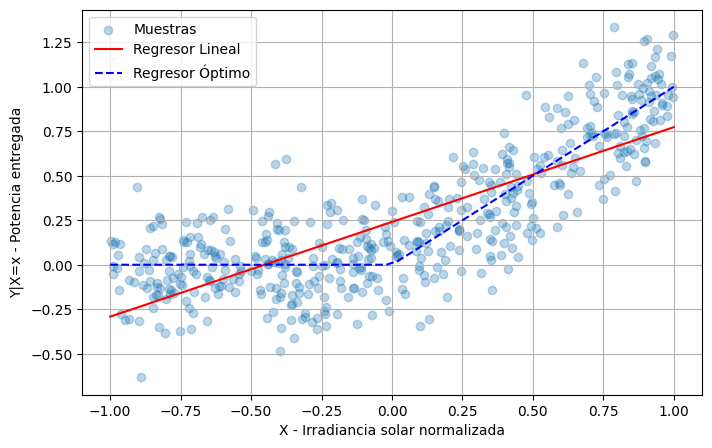

In [ ]:
modelo_2 = RegLineal_2()
modelo_2.fit_gradient(X,Y,0.03)

#Error de entrenamiento
error = modelo_2.err_predict(X,Y)
print("Error de entrenamiento: ",error)

# Utilizar el regresor para predecir la potencia producida para una irradiancia de 0.5

irradiancia = np.array([0.5])
y_i = modelo_2.predict(irradiancia)
print("Predicción de Y con X = 0.5: ",y_i)

#Graficar el regresor obtenido superpuesto al ´optimo y al scatter.
plt.figure(figsize=(8,5))
plt.grid()
plt.scatter(X,Y,alpha=0.3,label="Muestras") #Muestras
# Regresor lineal aprendido
x_line = np.linspace(-1,1)
y_line = modelo_2.predict(x_line)
plt.plot(x_line,y_line,label="Regresor Lineal",color = "red")
plt.plot(x_line,np.where(x_line > 0, x_line,0),'b--',label="Regresor Óptimo")
plt.xlabel("X - Irradiancia solar normalizada")
plt.ylabel("Y|X=x - Potencia entregada")
plt.legend()
plt.show()

Luego se procedio a graficar la pendiente de w con respecto a las iteraciones, podemos ver que efectivamente la pendiente de w tiende a 0.5, como lo es el valor predicho de Y con respecto a la irradiancia de X.

MSE del gradiente descendiente:  0.24568248617944413
Predicción de Y con X = 0.5:  [[0.50699511]]


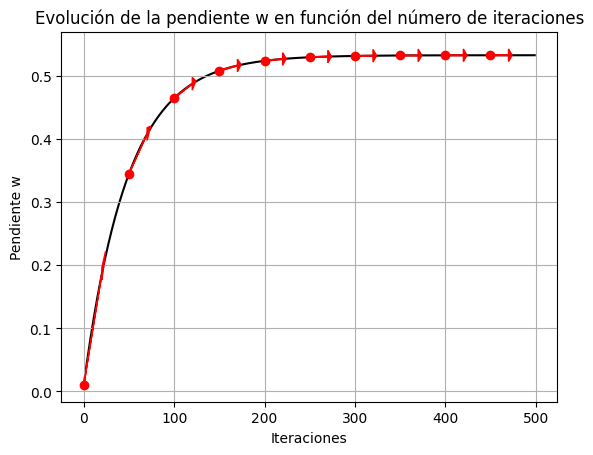

In [ ]:


#Error de entrenamiento
error_2 = modelo_2.err_predict(X,Y)
print("MSE del gradiente descendiente: ",error_2)

# Utilizar el regresor para predecir la potencia producida para una irradiancia de 0.5

irradiancia = np.array([0.5])
y_2 = modelo_2.predict(irradiancia)
print("Predicción de Y con X = 0.5: ",y_2)

# Pendiente de w
w = np.array(modelo_2.w)
n = len(w)

x_line_2 = np.linspace(-1,1)
y_line_2 = modelo_2.predict(x_line_2)
plt.plot(range(n), w, color = "black",zorder=1)

iteracion = np.arange(0, n, 50)
plt.scatter(iteracion, w[iteracion], color='red', zorder=2)  # puntos grandes y visibles
# Dibujar flechas en esos mismos puntos hacia el siguiente
for i in iteracion[:]:
    plt.arrow(i, w[i], 20, w[i+20]-w[i], head_width=0.02, head_length=4, fc='red', ec='red', zorder=3)

plt.grid()
plt.xlabel("Iteraciones")
plt.ylabel("Pendiente w")
plt.title("Evolución de la pendiente w en función del número de iteraciones")
plt.show()